# Notebook for experimenting different toy stellar wind models for modeling X-Ray Light Curves

In [13]:
# --- Repo-root bootstrap: run this cell first ---
# These notebooks live in notebooks/, but the project modules imported below and
# the ./data and ./analyses paths used throughout are all relative to the repo
# root. Make the root the working directory and put it on sys.path.
import os
import sys
from pathlib import Path

ROOT = next(
    (p for p in [Path.cwd(), *Path.cwd().parents] if (p / "xrb_lightcurve.py").exists()),
    None,
)
if ROOT is None:
    raise RuntimeError(
        f"Could not find the repo root (no xrb_lightcurve.py at or above {Path.cwd()})."
    )

os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print(f"repo root : {ROOT}")
print(f"cwd       : {Path.cwd()}")

repo root : /Users/rpanchal/Desktop/xrb_lc/XRB_LightCurve
cwd       : /Users/rpanchal/Desktop/xrb_lc/XRB_LightCurve


In [14]:
from plot_results import *
from chandra_phase_analysis import *
from compute_flux_vs_nH import *
from xrb_lightcurve import *
import pandas as pd
import numpy as np
import os
from xspec import (
        AllData,
        AllModels,
        Spectrum,
        Model,
        Fit,
        Xset,
        Plot,
)

## ObsID 15803 in Broad band (0.5-7.0 KeV)

Loading 1 observation file(s) from ./data/IC_10_X1_LC_CIAO/broad/single
Removed 56 zero/NaN flux data points (1442 remaining)


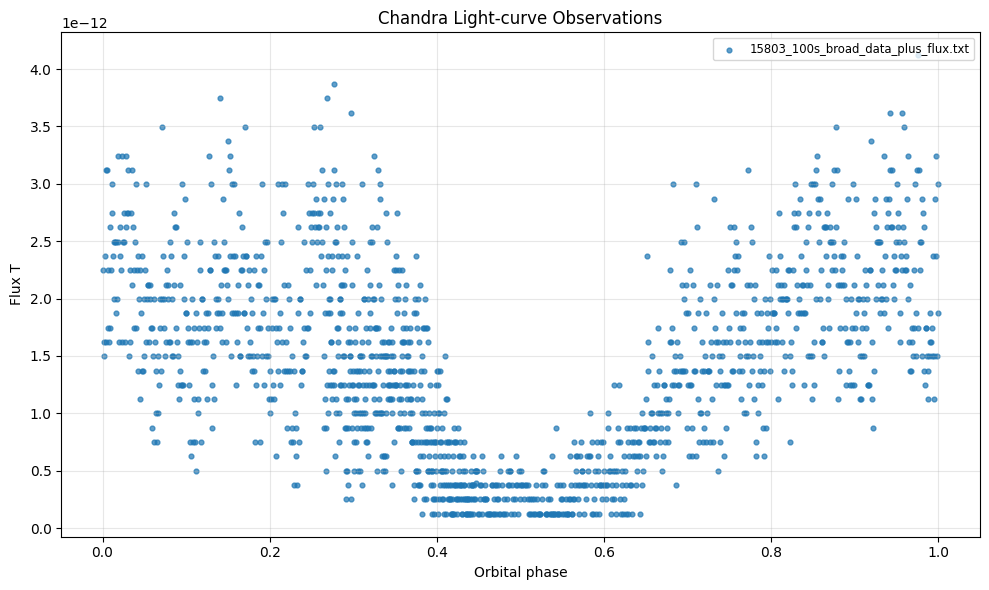

In [15]:
# Plot broad band LC
obs_column = "flux_t"
time_column = "t_raw"
data = load_data("./data/IC_10_X1_LC_CIAO/broad/single", obs_column = obs_column, time_column = time_column)
n_before = len(data)
data_df = data[(data['rate'] != 0) & (data['rate'].notna())].reset_index(drop=True)
n_removed = n_before - len(data_df)
if n_removed > 0:
    print(f"Removed {n_removed} zero/NaN flux data points ({len(data_df)} remaining)")
plot_phase(data_df, None, obs_column_name = obs_column)

Adaptive phase binning: 1442 points -> 129 bins (target 120 counts/bin, avg 128.3)
Smoothing: 129 points, sigma=0.0100, eval=300, n_mc=1000


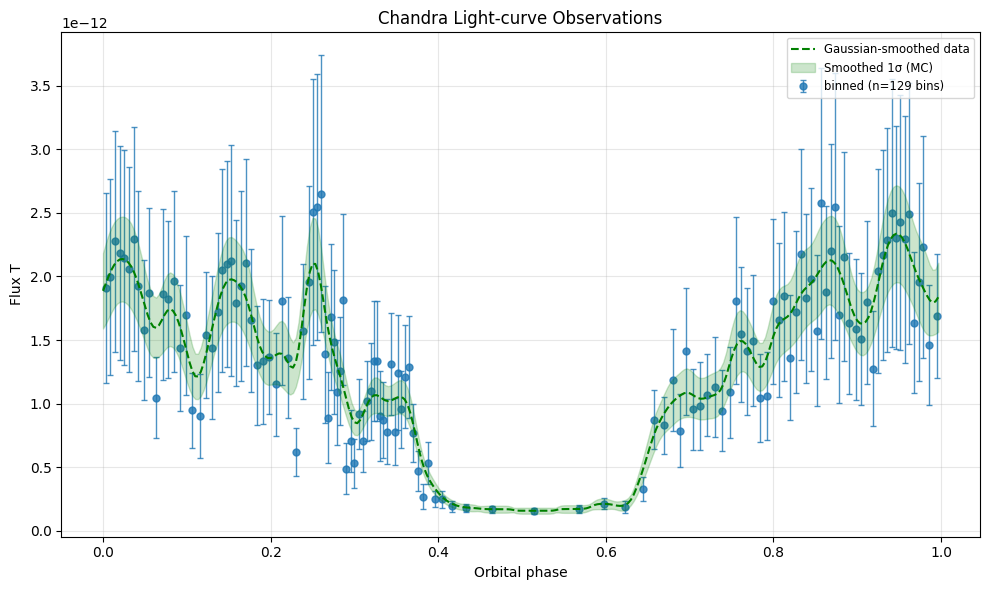

In [20]:
# Binned by constant signal-to-noise
df = phase_bin_data_snr(
    data_df,
    counts_per_bin=120,
    verbose=True
)
smooth_df = smooth_lightcurve(
                df["phase"].to_numpy(dtype=float),
                df["rate"].to_numpy(dtype=float),
                df["error"].to_numpy(dtype=float) if "error" in df.columns else None,
                sigma=0.01,
                n_mc=1000,
                random_state=None,
                verbose=True,
            )
plot_phase(df, None, sim_df = None, shift = None, chi2 = None,
            shift_fitted=False, obs_column_name=obs_column, is_binned=True, smooth_df=smooth_df)

### Smoothly Broken Power-law wind

In [21]:
scatter_value = estimate_scattered_flux(
                df["phase"].to_numpy(dtype=float),
                df["rate"].to_numpy(dtype=float),
                window=(0.4, 0.6),
)
print(f"Estimated scattered flux from eclipse window: {scatter_value:.6g}")

Estimated scattered flux from eclipse window: 1.91445e-13


Best-fit parameters (phase shift only, no flux rescaling):
  Phase shift = 0.01130
  Scattered flux = 1.91445e-13 (fixed, additive)
  Reduced χ² = 1.382  (dof = 128)


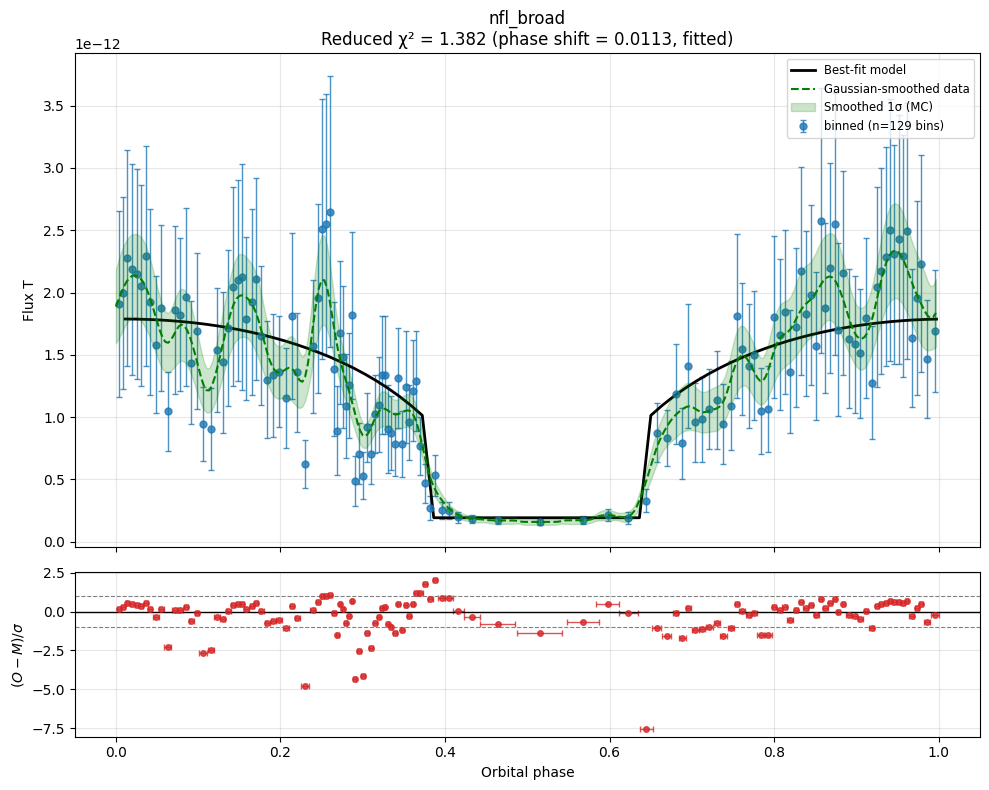

In [22]:
# Smooth powerlaw wind model
wind_params = {"Rb": 26.474333, "p": 5.461951, "Delta": 2}
sim_df = simulate_lightcurve(
        r=0.060828,
        R=13.521006,
        d1=10.677239,
        d2=7.123428,
        gma0=-90,
        i0=15.237285,
        dth=5,
        d2h=30,
        dz=0.5,
        verbose=False,
        n_jobs=1,
        flux_method="interpolate",
        flux_csv_path="./analyses/flux_vs_nH_tbabs_15803_broad.csv",
        flux_type="erg",
        lam=0.533545,
        Rmax=None,
        converge_rmax=True,
        wind_model="smooth_pl",
        wind_params=wind_params,
    )
is_binned = True
sim_columns = detect_flux_columns(sim_df)
shift, chi2 = fit_simulation(df, sim_df, sim_columns[0], fit_phase_shift=True, scatter=1.91445e-13)
plot_phase(df, None, sim_df, shift, sim_columns[0], chi2,
            shift_fitted=True, obs_column_name=obs_column, is_binned=True,
            smooth_df=smooth_df, scatter=1.92174e-13)

### Velocity based density model

Phase binning: 1367 points -> 144 bins (avg 9.1 points/bin)
Chi-square (no rescaling):
  Phase shift = 0.00000 (fixed)
  Scale factor = 1.00000 (fixed)
  Reduced χ² = 26.718


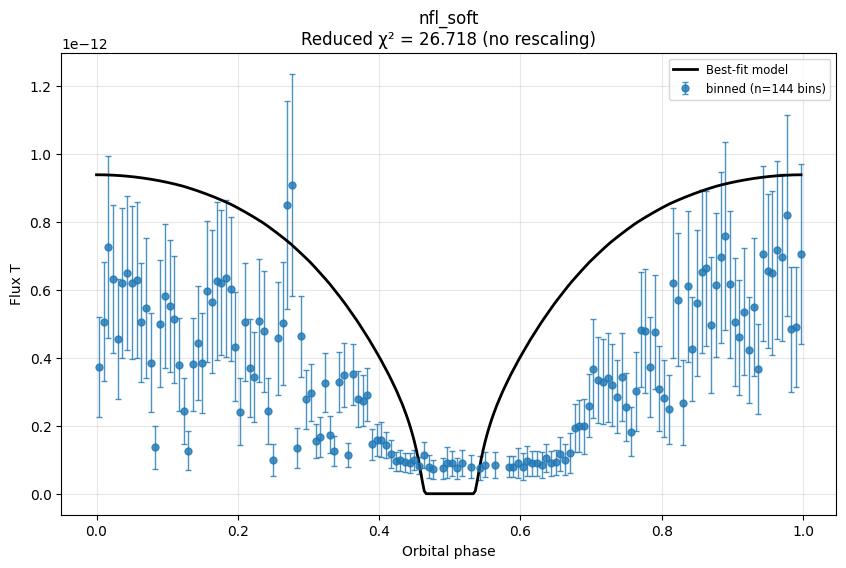

In [19]:
# Beta law wind model
R = 8
wind_params = {"beta": 0.5, "H": 1.0, "R_star": R}
sim_df = simulate_lightcurve(
        r=0.01,
        R=R,
        d1=11,
        d2=8,
        gma0=-90,
        i0=22,
        dth=1,
        d2h=6,
        dz=0.5,
        verbose=False,
        n_jobs=7,
        flux_method="interpolate",
        flux_csv_path="./analyses/flux_vs_nH_tbabs_15803_soft.csv",
        flux_type="erg",
        lam=0.533545,
        Rmax=None,
        converge_rmax=True,
        wind_model="beta_law",
        wind_params=wind_params,
    )
df = phase_bin_data(
    data_df,
    n_bins=150,
    min_points_per_bin=5,
    rate_column='rate',
    error_column='error',
    verbose=True
)
is_binned = True
sim_columns = detect_flux_columns(sim_df)
shift, chi2 = fit_simulation(df, sim_df, sim_columns[0], fit_phase_shift=False)
plot_phase(df, None, sim_df, shift, sim_columns[0], chi2,
            shift_fitted=False, obs_column_name=obs_column, is_binned=is_binned)

### Inner confinement or compression model

Phase binning: 1367 points -> 144 bins (avg 9.1 points/bin)
Chi-square (no rescaling):
  Phase shift = 0.00000 (fixed)
  Scale factor = 1.00000 (fixed)
  Reduced χ² = 8.268


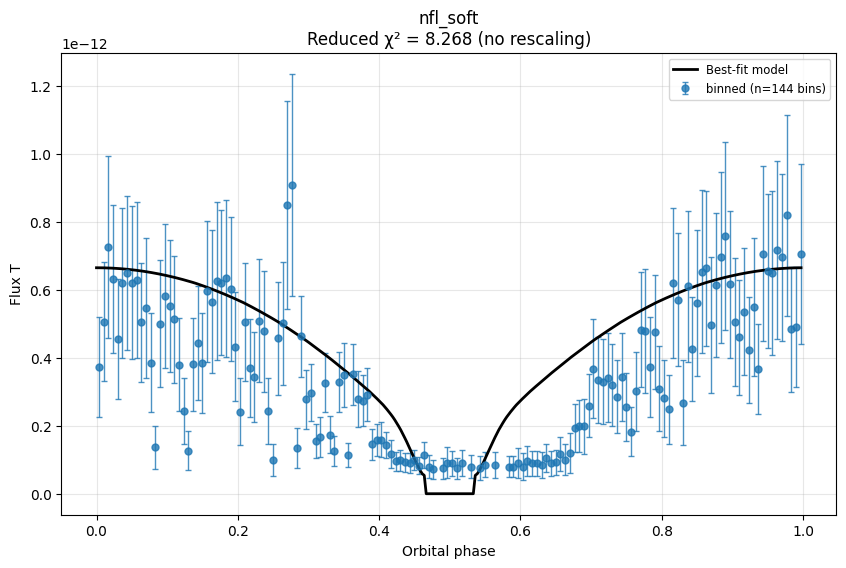

In [16]:
# Confinement wind model
R = 7.5
wind_params = {"fconf": 5.0, "ell": 0.6, "R_star": R}
sim_df = simulate_lightcurve(
        r=0.074665,
        R=R,
        d1=7.23,
        d2=6.70,
        gma0=-90,
        i0=30,
        dth=1,
        d2h=6,
        dz=0.5,
        verbose=False,
        n_jobs=7,
        flux_method="interpolate",
        flux_csv_path="./analyses/flux_vs_nH_tbabs_15803_soft.csv",
        flux_type="erg",
        lam=0.533545,
        Rmax=None,
        converge_rmax=True,
        wind_model="confinement",
        wind_params=wind_params,
    )
df = phase_bin_data(
    data_df,
    n_bins=150,
    min_points_per_bin=5,
    rate_column='rate',
    error_column='error',
    verbose=True
)
is_binned = True
sim_columns = detect_flux_columns(sim_df)
shift, chi2 = fit_simulation(df, sim_df, sim_columns[0], fit_phase_shift=False)
plot_phase(df, None, sim_df, shift, sim_columns[0], chi2,
            shift_fitted=False, obs_column_name=obs_column, is_binned=is_binned)